---

# table of contents

1.  [Shor's Algorithm](#shors-algorithm)
2.  [Circuit construction](#Circuit-construction)
   - [Classical Post-Processing](#classical-post-processing)
   - [Simulation Parameters](#simulation-parameters)
   - [`run_shor` — Full Execution Pipeline](#run_shor--full-execution-pipeline)
   - [Factoring $N = 15$](#factoring-n--15)
   - [Factoring $N = 33$](#factoring-n--33)
   - [Factoring $N = 55$](#factoring-n--55)
   - [Factoring $N = 65$](#factoring-n--65)
   - [Factoring $N = 133$](#factoring-n--133)
   -  [Measurement Distribution](#measurement-distribution)
   -  [Scaling Analysis](#scaling-analysis)
3. [Optimization Strategies](#optimization-strategies)
   - [Memory-Efficient Simulation](#memory-efficient-simulation)
   - [Optimized Shor Implementation](#optimized-shor-implementation)
4. [RSA Breaking](#rsa-breaking)
   - [RSA Cryptography Background](#rsa-cryptography-background)
   - [Demonstration](#demonstration)

---

# Shor's Algorithm

#### 1.1 Classical Reduction  

The factoring problem is reduced to **order-finding**:

1. **Choose random integer** $a < N$ (coprime to $N$)
2. **Check for trivial factors**: Compute $\gcd(a, N)$ 
3. **Extract factors from period**: Once quantum subroutine returns period $r$, compute:
   $$\gcd(a^{r/2} \pm 1, N)$$

#### 1.2 Quantum Order-Finding 

Find the period $r$ of the function $f(x) = a^x \mod N$ using:

1. **Initialization**: Create superposition of all possible states
   $$|\psi_0\rangle = \frac{1}{\sqrt{2^n}}\sum_{x=0}^{2^n-1} |x\rangle|0\rangle$$

2. **Modular Exponentiation**: Apply unitary transformation
   $$U_f|x\rangle|0\rangle \rightarrow |x\rangle|a^x \mod N\rangle$$

3. **Quantum Fourier Transform**: Apply inverse QFT to extract period via constructive interference

4. **Measurement**: Measure to obtain value allowing computation of $r$ via continued fractions



In [ ]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from math import gcd
from fractions import Fraction

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

from modexp import ModExpTools, binary_to_decimal

plt.style.use('default')
%matplotlib inline

## Circuit construction
The quantum circuit for Shor's algorithm is an application of **Quantum Phase Estimation (QPE)** for period finding. It requires:

- **x register**: $n_x$ qubits for phase estimation (controls)
- **z register**: $n$ qubits storing result of $a^x \mod N$ (initialized to $|1\rangle$)
- **ancilla**: Additional qubits for arithmetic operations
- **$U$**: Modular exponentiation operator $U|y\rangle = |ay \mod N\rangle$


The following cell defines `build_shor_circuit(N, a, n, nx)`, which assembles the full Shor's algorithm circuit:

1. Allocates the **x register** ($n_x$ qubits) and the **z register** ($n$ qubits)
2. Applies **Hadamard** gates to the x register to create uniform superposition
3. Initializes the z register to $|1\rangle$
4. Appends the **modular exponentiation gate** $U_f$ controlled on each qubit of x
5. Applies the **inverse QFT** to the x register to extract the period
6. Adds **measurement** on the x register


In [22]:
def build_shor_circuit(N: int, a: int, n: int, nx: int):
    """
    Build complete Shor's algorithm circuit.
    
    Parameters:
    N : int
        Number to factor
    a : int
        Base for modular exponentiation (coprime to N)
    n : int
        Number of bits for N
    nx : int
        Number of bits for exponent (precision parameter)
    
    """
    # all registers
    x = QuantumRegister(nx, 'x')      # control/exponent register
    z = QuantumRegister(n, 'z')       # result register (|1> initial state)
    a_reg = QuantumRegister(n, 'a')   # temporary workspace
    b = QuantumRegister(n + 1, 'b')   # accumulator
    c = QuantumRegister(n, 'c')       # carry bits
    bN = QuantumRegister(n, 'bN')     # s
    t = QuantumRegister(1, 't')       # temporary flag
    cr = ClassicalRegister(nx, 'c1')  # classical measurement register
    
    qc = QuantumCircuit(x, z, a_reg, b, c, bN, t, cr)
    
    # result register to 1
    qc.x(z[0]) 
    
    # modulus register 
    tempN = N
    for i in range(n):
        if tempN % 2 != 0:
            qc.x(bN[i])
        tempN //= 2
    
    # create superposition in control register
    for i in range(nx):
        qc.h(x[i])
    
    qc.barrier()
    

    # controlled modular exponentiation
    modexp = ModExpTools.create_mod_exp(n, N, a, nx)
    qc.append(modexp, list(x) + list(z) + list(a_reg) + list(b) + list(c) + list(bN) + list(t))
    
    qc.barrier()
    

    # I-QFT
    qft_inv = ModExpTools.myqft(nx).inverse()
    qc.append(qft_inv, list(x))
    
    qc.barrier()
    
    qc.measure(x, cr)
    
    return qc


shor_circuit = build_shor_circuit(N=35, a=2, n=6, nx=12)

print(f"Shor's algorithm circuit built successfully!")
print(f"Total qubits: {shor_circuit.num_qubits}")
print(f"Circuit depth: {shor_circuit.depth()}")
print(f"Gate count: {shor_circuit.size()}")

Shor's algorithm circuit built successfully!
Total qubits: 44
Circuit depth: 4
Gate count: 30


## Classical Post-Processing

After measuring the control register, we obtain a value $m$ such that:
$$m \approx \frac{k \cdot 2^{n_x}}{r}$$

where $k$ is a random integer and $r$ is the period we seek.

- uses **continued fractions** to find the best rational approximation $k/r$. The following cell defines `extract_period`, which converts a binary measurement string into a period candidate $r$ and attempts to factor $N$ via $\gcd(a^{r/2} \pm 1, N)$.


In [23]:
def extract_period(measurement: str, nx: int, N: int, a: int):
    """
    Extract period from QPE measurement using continued fractions.
    
    Parameters:
    measurement : str
        Binary measurement string
    nx : int
        Number of control qubits
    N : int
        Number being factored
    a : int
        Base for exponentiation
    
    """

    measured_value = binary_to_decimal(measurement)
    
    if measured_value == 0:
        return None
    
    phase = measured_value / (2 ** nx)
    
    # continued fractions
    frac = Fraction(phase).limit_denominator(N)
    r_candidate = frac.denominator
    
    if pow(a, r_candidate, N) == 1:
        return r_candidate
    
    return None


def factor_from_period(N: int, a: int, r: int):
    """
    Extract factors from period using gcd.
    
    Given period r such that a^r ≡ 1 (mod N), compute:
    - p = gcd(a^(r/2) - 1, N)
    - q = gcd(a^(r/2) + 1, N)
    
    Parameters:
    N : int
        Number to factor
    a : int
        Base
    r : int
        Period
    
"""
    # Period must be even
    if r % 2 != 0:
        return None
    
    # Compute a^(r/2) mod N
    x = pow(a, r // 2, N)
    
    # Avoid trivial case
    if x == N - 1:
        return None
    
    # Extract factors
    p = gcd(x - 1, N)
    q = gcd(x + 1, N)
    
    # Check for nontrivial factors
    if p > 1 and p < N and q > 1 and q < N:
        return (p, q)
    elif p > 1 and p < N:
        return (p, N // p)
    elif q > 1 and q < N:
        return (q, N // q)
    
    return None

## Simulation Parameters

The following cell defines the parameter dictionaries for five factoring targets: $N \in \{15, 21, 33, 65, 133\}$. Each entry specifies the base $a$, the register sizes $n$ and $n_x$, the number of shots, and the Aer backend method (`matrix_product_state`).


In [ ]:
# N = 15 (3 × 5)
params_15 = {
    'N': 15,
    'a': 7,              
    'n': 5,
    'nx': 12,
    'shots': 2048,       
    'backend_method': 'matrix_product_state'
}

# N = 21 (3 × 7)
params_21 = {
    'N': 21,
    'a': 2,
    'n': 6,              
    'nx': 15,            
    'shots': 2048,
    'backend_method': 'matrix_product_state'
}

# N = 33 (3 × 11)
params_33 = {
    'N': 33,
    'a': 7,              
    'n': 6,
    'nx': 15,            
    'shots': 4096,       
    'backend_method': 'matrix_product_state'
}

# N = 55 (5 × 11)
params_55 = {
    'N': 55,
    'a': 2,              
    'n': 6,
    'nx': 15,
    'shots': 4096,       
    'backend_method': 'matrix_product_state'
}

# N = 65 (5 × 13)
params_65 = {
    'N': 65,
    'a': 11,
    'n': 7,
    'nx': 22,
    'shots': 4096,       
    'backend_method': 'matrix_product_state'
}

# N = 133 (7 × 19)
params_133 = {
    'N': 133,
    'a': 2,
    'n': 8,
    'nx': 20,
    'shots': 4096,       
    'backend_method': 'matrix_product_state'
}

'''
# N = 437 (19 × 23)
params_437 = {
    'N': 437,
    'a': 2,
    'n': 9,
    'nx': 22,
    'shots': 8192,      
    'backend_method': 'stabilizer'
}'''


Different Aer simulation methods support different maximum qubit counts before becoming intractable. The following cell queries each available backend method and prints how many qubits it can handle, helping to select the most suitable method (`matrix_product_state` or `tensor_network`) for large circuits.


In [25]:
# check how many qubits have matrix_product_state and tensor_network backends
from qiskit_aer import AerSimulator
sim_mps = AerSimulator(method='matrix_product_state')
# check all ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
for method in ['automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop']:
    sim = AerSimulator(method=method)
    print(f"Max qubits for {method}: {sim.configuration().n_qubits}")

Max qubits for automatic: 29
Max qubits for statevector: 29
Max qubits for density_matrix: 14
Max qubits for stabilizer: 10000
Max qubits for matrix_product_state: 63
Max qubits for extended_stabilizer: 63
Max qubits for unitary: 14
Max qubits for superop: 7


## `run_shor` — Full Execution Pipeline

The following cell defines `run_shor(N, a, n, nx, shots, backend_method)`, which orchestrates the full algorithm: builds the circuit via `build_shor_circuit`, transpiles it for the chosen Aer backend, executes the simulation, and calls `extract_period` on each measurement outcome to return the prime factors $p$ and $q$ (or a failure flag).


In [26]:
import time

def run_shor(N: int, a: int, n: int, nx: int, shots: int = 1024, backend_method: str = "matrix_product_state"):
    """
    Execute complete Shor's algorithm.
    
    Parameters
    ----------
    N : int
        Number to factor
    a : int
        Coprime base
    n : int
        Number of bits for N
    nx : int
        Number of control qubits
    shots : int
        Number of measurements
    backend_method : str
        Simulation method
    
    Returns
    -------
    dict
        Results including factors and measurement counts
    """
    qc = build_shor_circuit(N, a, n, nx)
    #qc.draw('mpl', fold=-1)
    from qiskit_aer import AerSimulator
    backend_mps = AerSimulator(method=backend_method)
    t_qc = transpile(qc, backend_mps)
    job = backend_mps.run(t_qc, shots=1024)
    counts = job.result().get_counts()


    print(f"\n{'='*60}")
    print(f"Analyzing {len(counts)} unique measurement outcomes...")
    print(f"{'='*60}\n")
    
    for measurement, count in sorted(counts.items(), key=lambda x: -x[1])[:10]:

        r = extract_period(measurement, nx, N, a)
        
        if r is not None:
            print(f"Measurement: {measurement} (count: {count:4d})")
            print(f"Decimal: {binary_to_decimal(measurement)}")
            print(f"Candidate period: r = {r}")
            
            # Try to extract factors
            factors = factor_from_period(N, a, r)
            
            if factors is not None:
                p, q = factors
                print(f"SUCCESS! Factors found: {p} × {q} = {p*q}")
                print(f"\n{'='*60}\n")
                return {
                    'success': True,
                    'p': p,
                    'q': q,
                    'period': r,
                    'measurement': measurement,
                    'counts': counts
                }
            else:
                print(f"Period found but factorization failed")
        print()
        
    return {
        'success': False,
        'counts': counts
    }


### Factoring $N = 15$

The following cell runs Shor's algorithm for $N = 15 = 3 \times 5$ using the `params_15` configuration and prints whether factorization succeeded, the factors found, and the wall-clock execution time.


In [27]:
# Run the algorithm
print("Running Shor's algorithm...\n")
start_time = time.time()
result = run_shor(**params_15)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")
if result['success']:
    print(f"\n Factorization successful!")
    print(f"{params_15['N']} = {result['p']} × {result['q']}")
else:
    print("\nFactorization unsuccessful in this run.")
    print("Try increasing shots or nx parameter.")

Running Shor's algorithm...




Analyzing 4 unique measurement outcomes...



Measurement: 110000000000 (count:  253)
Decimal: 3072
Candidate period: r = 4
SUCCESS! Factors found: 3 × 5 = 15


Execution time: 14.91 seconds

 Factorization successful!
15 = 3 × 5


### Factoring $N = 33$

The following cell runs the algorithm for $N = 33 = 3 \times 11$ and reports the result.


In [28]:
# Run the algorithm
print("Running Shor's algorithm...\n")
start_time = time.time()
result = run_shor(**params_33)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")
if result['success']:
    print(f"\nFactorization successful!")
    print(f"{params_33['N']} = {result['p']} × {result['q']}")
else:
    print("\nFactorization unsuccessful in this run.")
    print("Try increasing shots or nx parameter.")

Running Shor's algorithm...




Analyzing 69 unique measurement outcomes...




Measurement: 000110011001101 (count:   97)
Decimal: 3277
Candidate period: r = 10
SUCCESS! Factors found: 3 × 11 = 33


Execution time: 39.94 seconds

Factorization successful!
33 = 3 × 11


### Factoring $N = 55$ 

The following cell contains the run for $N = 55 = 5 \times 11$. It is currently commented out because the circuit size makes simulation slow; uncomment to enable.


In [29]:
# Run the algorithm
print("Running Shor's algorithm...\n")
start_time = time.time()
result = run_shor(**params_55)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")
if result['success']:
    print(f"\n Factorization successful!")
    print(f"{params_55['N']} = {result['p']} × {result['q']}")
else:
    print("\n  Factorization unsuccessful in this run.")
    print("  Try increasing shots or nx parameter.")

'# Run the algorithm\nprint("Running Shor\'s algorithm...\n")\nstart_time = time.time()\nresult = run_shor(**params_55)\nend_time = time.time()\nprint(f"Execution time: {end_time - start_time:.2f} seconds")\nif result[\'success\']:\n    print(f"\n Factorization successful!")\n    print(f"{params_55[\'N\']} = {result[\'p\']} × {result[\'q\']}")\nelse:\n    print("\n  Factorization unsuccessful in this run.")\n    print("  Try increasing shots or nx parameter.")'

### Factoring $N = 65$

The following cell runs Shor's algorithm for $N = 65 = 5 \times 13$ and reports the result.


In [30]:
# Run the algorithm
print("Running Shor's algorithm...\n")
start_time = time.time()
result = run_shor(**params_65)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")
if result['success']:
    print(f"\n Factorization successful!")
    print(f" {params_65['N']} = {result['p']} × {result['q']}")
else:
    print("\n Factorization unsuccessful in this run.")
    print(" Try increasing shots or nx parameter.")

Running Shor's algorithm...


Analyzing 71 unique measurement outcomes...





Measurement: 0110101010101010101011 (count:   69)
Decimal: 1747627
Candidate period: r = 12
SUCCESS! Factors found: 5 × 13 = 65


Execution time: 81.14 seconds

 Factorization successful!
 65 = 5 × 13


### Factoring $N = 133$

The following cell runs the algorithm for $N = 133 = 7 \times 19$, the largest test case, and reports the result and execution time.

In [31]:
# Run the algorithm
print("Running Shor's algorithm...\n")
start_time = time.time()
result = run_shor(**params_133)
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")
if result['success']:
    print(f"\n Factorization successful!")
    print(f" {params_133['N']} = {result['p']} × {result['q']}")
else:
    print("\nFactorization unsuccessful in this run.")
    print("Try increasing shots or nx parameter.")

Running Shor's algorithm...




Analyzing 92 unique measurement outcomes...

Measurement: 01000111000111000111 (count:   64)
Decimal: 291271
Candidate period: r = 18
SUCCESS! Factors found: 7 × 19 = 133


Execution time: 155.85 seconds

 Factorization successful!
 133 = 7 × 19


### Measurement Distribution

The following cell plots the **histogram of measurement outcomes** for the last simulation run (N=133). Peaks in the histogram correspond to multiples of $2^{n_x}/r$, visually confirming which values of $m$ the QPE concentrates probability on.


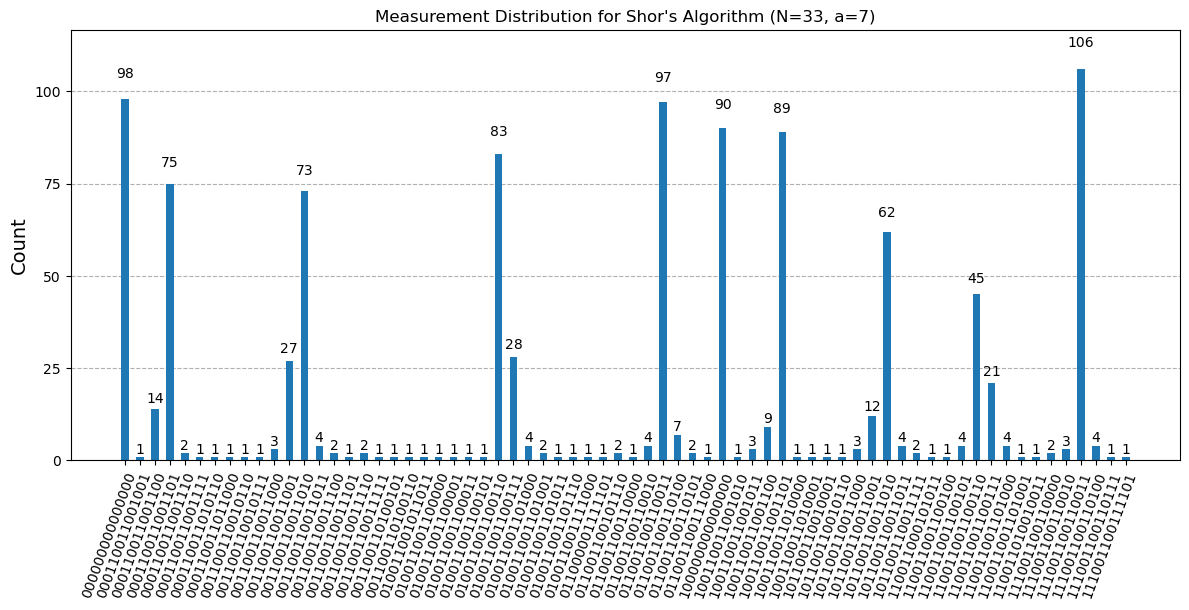

In [ ]:
# Visualize measurement distribution
if 'counts' in result:
    fig = plot_histogram(result['counts'], figsize=(12, 6))
    plt.title(f"Measurement Distribution for Shor's Algorithm (N={params_33['N']}, a={params_33['a']})")
    plt.show()


### Scaling Analysis

The following cell plots simulation **wall-clock time** as a function of $N$ (and the equivalent bit-length $L = \lceil \log_2 N \rceil$) across three independent runs, with error bars from the standard error of the mean. The fit illustrates the polynomial growth of classical simulation cost as circuit size increases.


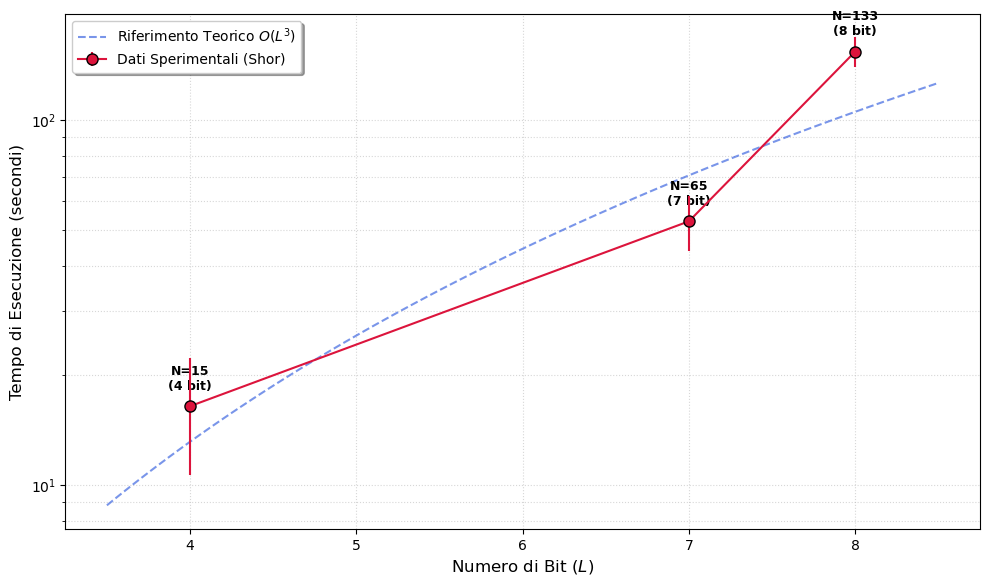

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_values = np.array([15, 65, 133])
tempi_1 = np.array([6.25, 30.93, 119.15])
tempi_2 = np.array([30.23, 67.53, 174.20])
tempi_3 = np.array([12.97, 60.11, 168.89])
tempi = (tempi_1 + tempi_2 + tempi_3) / 3
# errore
errore_tempi = np.std([tempi_1, tempi_2, tempi_3], axis=0) / np.sqrt(3)


# L = ceil(log2(N))
L_bits = np.ceil(np.log2(N_values))

k = np.mean(tempi[:2] / (L_bits[:2]**3)) 
L_line = np.linspace(min(L_bits) - 0.5, max(L_bits) + 0.5, 100)
t_theory = k * (L_line**3)

plt.figure(figsize=(10, 6))

plt.plot(L_line, t_theory, color='royalblue', linestyle='--', alpha=0.7, 
         label='Riferimento Teorico $O(L^3)$')

plt.errorbar(L_bits, tempi, yerr=errore_tempi, color='crimson', marker='o', markersize=8, markeredgecolor='black',
            zorder=5, label='Dati Sperimentali (Shor)')

for i, txt in enumerate(N_values):
    plt.annotate(f'N={txt}\n({int(L_bits[i])} bit)', 
                 (L_bits[i], tempi[i]), 
                 textcoords="offset points", 
                 xytext=(0,12), ha='center', fontsize=9, fontweight='bold')


plt.yscale('log')
plt.xlabel('Numero di Bit ($L$)', fontsize=12)
plt.ylabel('Tempo di Esecuzione (secondi)', fontsize=12)
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## Optimization Strategies

### Memory-Efficient Simulation

For large circuits, standard state vector simulation becomes impractical due to exponential memory growth ($2^n$ complex amplitudes).

**Solutions:**
1. **Matrix Product State (MPS)**: Efficient for circuits with limited entanglement
2. **Tensor Network Methods**: Exploit circuit structure
3. **GPU Acceleration**: Parallelize state vector operations

###  Optimized Shor Implementation

In [ ]:
def shor_factor_optimized(N: int, 
                         shots: int = 4096,
                         max_tries: int = 30,
                         a_start: int = 2,
                         backend_method: str = "matrix_product_state",
                         n: int = None,
                         nx: int = None):
    """
    Optimized Shor's algorithm with automatic parameter selection.
    
    Parameters
    ----------
    N : int
        Number to factor
    shots : int
        Number of circuit executions
    max_tries : int
        Maximum number of different bases to try
    a_start : int
        Starting value for base a
    backend_method : str
        Qiskit Aer backend method:
        - 'statevector_simulator': Full state vector (small circuits)
        - 'matrix_product_state': MPS approximation (large circuits)
        - 'qasm_simulator': Shot-based simulation
    n : int, optional
        Override bit size for N
    nx : int, optional
        Override bit size for exponent
    
    Returns
    -------
    dict or None
        Factorization result with p, q, period, base
    """
    import math
    
    # Auto-determine bit sizes
    if n is None:
        n = math.ceil(math.log2(N)) + 1
    if nx is None:
        nx = 2 * n 
    
    print(f"\n{'='*70}")
    print(f"Optimized Shor's Algorithm - Factoring N = {N}")
    print(f"{'='*70}")
    print(f"Parameters:")
    print(f"  - n (bits for N): {n}")
    print(f"  - nx (exponent bits): {nx}")
    print(f"  - Total qubits: {nx + 5*n + 3}")
    print(f"  - Shots: {shots}")
    print(f"  - Backend: {backend_method}")
    print(f"{'='*70}\n")
    
    # Try different bases
    for i in range(max_tries):
        a = a_start + i
        
        # Check if a is coprime to N
        g = gcd(a, N)
        if g > 1:
            print(f"Base a = {a}: Found trivial factor via gcd: {g}")
            return {'p': g, 'q': N // g, 'period': None, 'a': a}
        
        print(f"\nAttempt {i+1}/{max_tries}: Trying base a = {a}...")
        
        # Run Shor's algorithm
        result = run_shor(N, a, n, nx, shots, backend_method)
        
        if result['success']:
            result['a'] = a
            return result
    
    print(f"\n  Failed to factor {N} after {max_tries} attempts.")
    return None

##  RSA Breaking 

### RSA Cryptography Background

RSA encryption relies on the difficulty of factoring large semiprimes:

1. **Key Generation**:
   - Choose primes $p, q$
   - Compute $N = pq$ (public)
   - Compute $\phi(N) = (p-1)(q-1)$ (private)
   - Choose public exponent $e$ coprime to $\phi(N)$
   - Compute private exponent $d = e^{-1} \pmod{\phi(N)}$

2. **Encryption**: $c = m^e \pmod{N}$
3. **Decryption**: $m = c^d \pmod{N}$

**Shor's algorithm breaks RSA** by factoring $N$ to recover $p$ and $q$, enabling computation of the private key $d$.

### Demonstration

We demonstrate breaking a toy RSA system:

In [ ]:
# RSA Setup (toy example)
N = 91  # Semiprime: 7 × 13
e = 5   # Public exponent

# plaintext message
m = 42
print(f"Original message: {m}")

# encrypt
c = pow(m, e, N)
print(f"Encrypted ciphertext: {c}")
print(f"\nPublic key: (N={N}, e={e})")
print(f"Private key: Unknown (attacker's goal)\n")

# attack
print(f"{'='*70}")
print(f"ATTACK: Using Shor's Algorithm to factor N = {N}")
print(f"{'='*70}\n")

# Factor N using Shor
result = shor_factor_optimized(
    N=N,
    shots=4096,
    max_tries=20,
    a_start=2,
    backend_method="matrix_product_state"
)

if result is None:
    print("\n Attack failed. Try increasing shots or max_tries.")
else:
    p, q = result['p'], result['q']
    
    print(f"\n{'='*70}")
    print(f" FACTORIZATION SUCCESSFUL!")
    print(f"{'='*70}")
    print(f"Factors: p = {p}, q = {q}")
    print(f"Verification: {p} × {q} = {p*q}")
    
    # Recover private key
    phi = (p - 1) * (q - 1)
    d = pow(e, -1, phi)  # Modular inverse
    
    print(f"\nRecovered private key:")
    print(f"  φ(N) = (p-1)(q-1) = {phi}")
    print(f"  d = e^(-1) mod φ(N) = {d}")
    
    # Decrypt
    m_recovered = pow(c, d, N)
    
    print(f"\n{'='*70}")
    print(f"DECRYPTION RESULT")
    print(f"{'='*70}")
    print(f"Ciphertext: {c}")
    print(f"Decrypted message: {m_recovered}")
    print(f"Original message: {m}")
    print(f"\n Match: {m_recovered == m}")
    print(f"\n- RSA encryption successfully broken using quantum computing!")

Original message: 42
Encrypted ciphertext: 35

Public key: (N=91, e=5)
Private key: Unknown (attacker's goal)

ATTACK: Using Shor's Algorithm to factor N = 91


Optimized Shor's Algorithm - Factoring N = 91
Parameters:
  - n (bits for N): 8
  - nx (exponent bits): 16
  - Total qubits: 59
  - Shots: 4096
  - Backend: matrix_product_state


Attempt 1/20: Trying base a = 2...

Analyzing 74 unique measurement outcomes...








Measurement: 1110101010101011 (count:   60)
Decimal: 60075
Candidate period: r = 12
SUCCESS! Factors found: 7 × 13 = 91



 FACTORIZATION SUCCESSFUL!
Factors: p = 7, q = 13
Verification: 7 × 13 = 91

Recovered private key:
  φ(N) = (p-1)(q-1) = 72
  d = e^(-1) mod φ(N) = 29

DECRYPTION RESULT
Ciphertext: 35
Decrypted message: 42
Original message: 42

 Match: True

- RSA encryption successfully broken using quantum computing!
